# PROJECT NAME - Automated Sales Reporting & Analystics
   created by lavi kumar 
 ## Section - Exploratory Data Analysis 
Task
 1. Univariate Analysis 
 2. Bivariate Analsis
 3. Multivariate Analysis 
 4. Summary 

In [1]:
# libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statistics as sts
from IPython.display import display


In [2]:
# load dataset
dt4=pd.read_excel('C:\\Users\lavir\OneDrive\Pictures\Documents\Automated_Sales_Reporting\dataset\clean_dataset.xlsx')

In [3]:
dt4['Customer_Age'] = dt4['Customer_Age'].astype('Int64')
dt4.dtypes

Order_ID                 object
Customer_Age              Int64
Customer_Type            object
Restaurant_Type          object
Cuisine_Type             object
Delivery_Distance_KM    float64
Delivery_Time_Min         int64
Order_Value_USD         float64
Item_Count                int64
Weather_Condition        object
Traffic_Level            object
Customer_Rating         float64
Complaint_Flag           object
Refund_Flag              object
Revenue_USD             float64
Profit_USD              float64
City                     object
Month                    object
Quarter                   int64
Churn_Risk              float64
dtype: object

 Univariate Analysis 


In [4]:
# check missig values 
dt4.isna().sum()

Order_ID                   0
Customer_Age             364
Customer_Type              0
Restaurant_Type            0
Cuisine_Type               0
Delivery_Distance_KM       0
Delivery_Time_Min          0
Order_Value_USD         1045
Item_Count                 0
Weather_Condition          0
Traffic_Level              0
Customer_Rating            0
Complaint_Flag             0
Refund_Flag                0
Revenue_USD                0
Profit_USD                 0
City                       0
Month                      0
Quarter                    0
Churn_Risk               364
dtype: int64

Missing Value Summary
1. Customer_Age: 364 missing
2. Order_Value_USD: 1045 missing
3. Churn_Risk: 365 missing

Remaining 17 columns: No missing values

In [5]:
fill=['Customer_Age','Order_Value_USD','Churn_Risk']
# So, 3586 / 38610 * 100 = 9.29% of the data is missing. Since the dataset does not contain any cost-related column, we have no way to calculate the actual cost or true profit for these missing rows. Additionally, there is near-zero correlation between Profit_USD and Order_Value_USD, Revenue_USD, and Item_Count, which means no other column in the dataset can reliably predict the missing profit values. Therefore, instead of dropping ~9.29% of the data (which would mean losing a significant portion of records), I chose to fill the missing Profit_USD values with the median. Since profit can have outliers (some orders with very high or very low margins), median is a more robust central estimate than mean and helps maintain overall data accuracy without discarding usable rows from other columns.
for col in fill:
    dt4[col]=dt4[col].fillna(dt4[col].median())

In [6]:
# Again check after fill median
dt4.isna().sum()

Order_ID                0
Customer_Age            0
Customer_Type           0
Restaurant_Type         0
Cuisine_Type            0
Delivery_Distance_KM    0
Delivery_Time_Min       0
Order_Value_USD         0
Item_Count              0
Weather_Condition       0
Traffic_Level           0
Customer_Rating         0
Complaint_Flag          0
Refund_Flag             0
Revenue_USD             0
Profit_USD              0
City                    0
Month                   0
Quarter                 0
Churn_Risk              0
dtype: int64

In [7]:
# Step 2: Define the columns where negative values are not logically possible
# (e.g., distance, time, order value, item count, quarter, revenue)
cols_to_fix = [
    "Delivery_Distance_KM",
    "Delivery_Time_Min",
    "Order_Value_USD",
    "Item_Count",
    "Quarter",
    "Revenue_USD"
]
for col in cols_to_fix:
    dt4[col]=dt4[col].abs()

In [8]:
# statistics describe
dt4.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,38047.0,47.231398,37.479146,-5.0,32.0,46.0,60.0,999.0
Delivery_Distance_KM,38047.0,12.759015,7.066749,0.5,6.66,12.76,18.89,25.0
Delivery_Time_Min,38047.0,64.406707,31.794253,5.0,37.0,64.0,92.0,119.0
Order_Value_USD,38047.0,153.282085,83.895555,5.0,82.075,153.0,225.025,300.0
Item_Count,38047.0,7.502615,4.02636,1.0,4.0,8.0,11.0,14.0
Customer_Rating,38047.0,3.002707,1.153437,1.0,2.0,3.0,4.0,5.0
Revenue_USD,38047.0,252.555338,142.453467,5.0,129.64,252.5,375.06,500.0
Profit_USD,38047.0,89.550488,63.475717,-19.99,34.51,89.71,144.2,199.99
Quarter,38047.0,2.50661,1.114768,1.0,2.0,3.0,3.0,4.0
Churn_Risk,38047.0,50.075631,28.754756,0.0,25.44,50.01,74.8,100.0


In [9]:
# summary statistics for numerical column
numeric_col=dt4.select_dtypes(include='number').columns
summary=dt4[numeric_col].describe().T # summary all numerical columns
summary['median']=dt4[numeric_col].median() # add median column in summary 
summary['IQR']=summary['75%']-summary['25%'] # add IQR column in summary formula(Q3-Q1)
summary['skewness']=dt4[numeric_col].skew() # add skewnes column in summary 
summary  # show

,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Customer_Age,38047.0,47.231398,37.479146,-5.0,32.0,46.0,60.0,999.0,46.0,28.0,20.231391
Delivery_Distance_KM,38047.0,12.759015,7.066749,0.5,6.66,12.76,18.89,25.0,12.76,12.23,0.003498
Delivery_Time_Min,38047.0,64.406707,31.794253,5.0,37.0,64.0,92.0,119.0,64.0,55.0,0.00573
Order_Value_USD,38047.0,153.282085,83.895555,5.0,82.075,153.0,225.025,300.0,153.0,142.95,-0.010495
Item_Count,38047.0,7.502615,4.02636,1.0,4.0,8.0,11.0,14.0,8.0,7.0,-0.005284
Customer_Rating,38047.0,3.002707,1.153437,1.0,2.0,3.0,4.0,5.0,3.0,2.0,-0.008367
Revenue_USD,38047.0,252.555338,142.453467,5.0,129.64,252.5,375.06,500.0,252.5,245.42,0.000448
Profit_USD,38047.0,89.550488,63.475717,-19.99,34.51,89.71,144.2,199.99,89.71,109.69,0.005949
Quarter,38047.0,2.50661,1.114768,1.0,2.0,3.0,3.0,4.0,3.0,1.0,-0.013808
Churn_Risk,38047.0,50.075631,28.754756,0.0,25.44,50.01,74.8,100.0,50.01,49.36,-0.005856


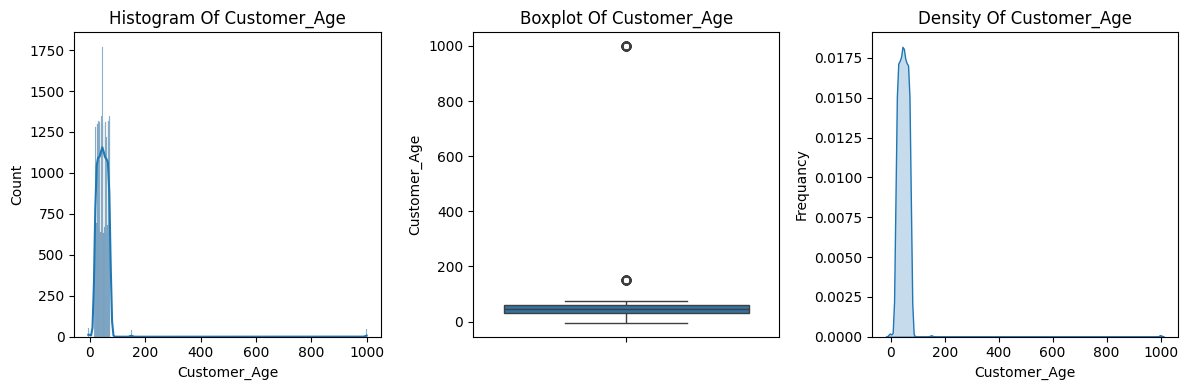

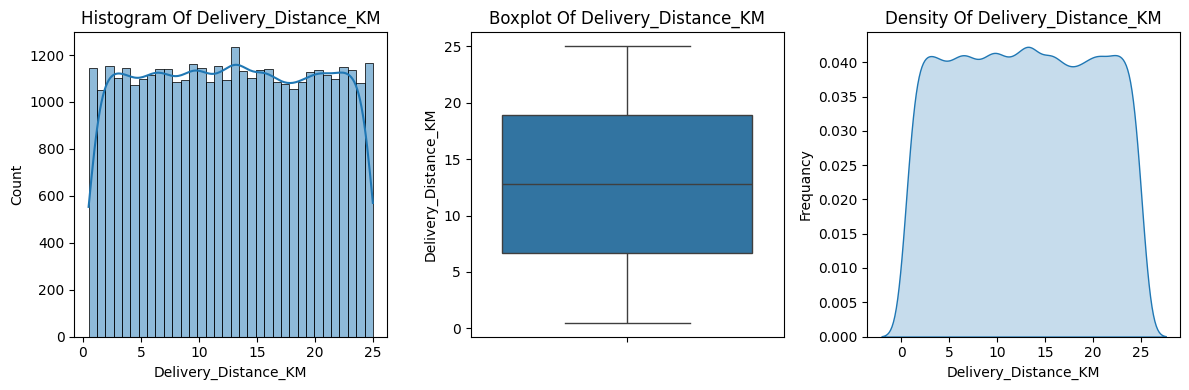

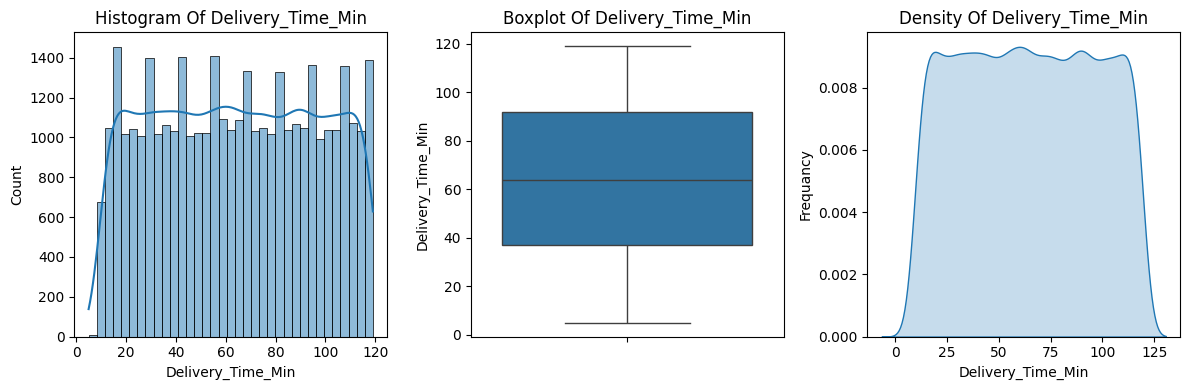

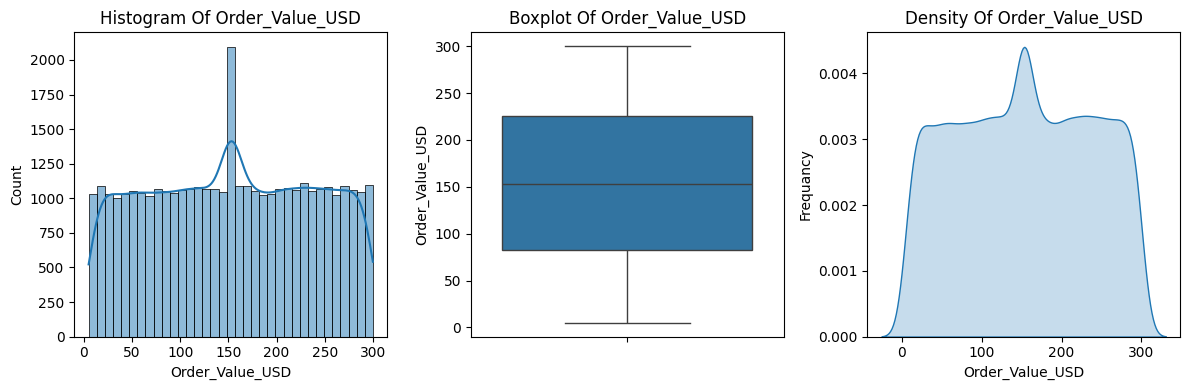

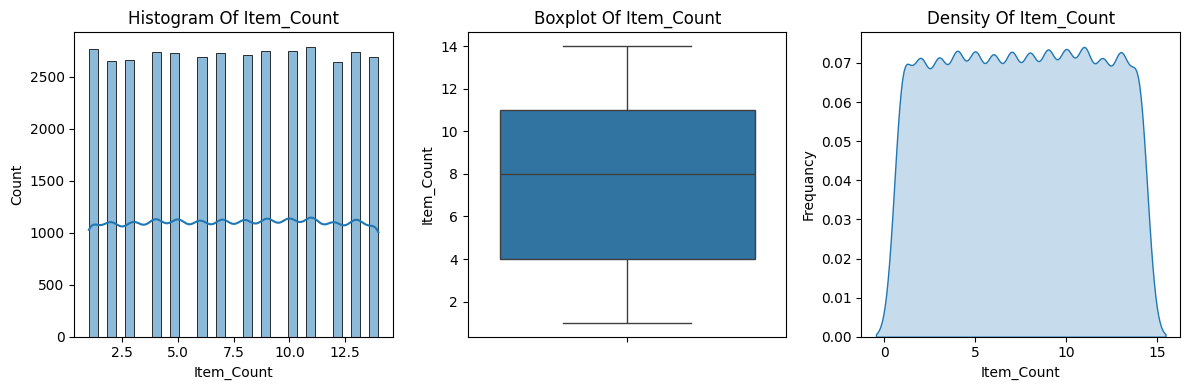

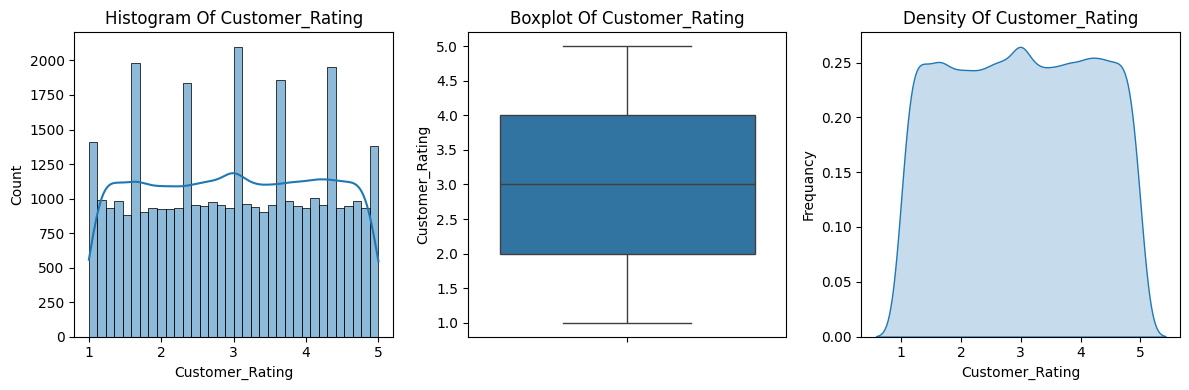

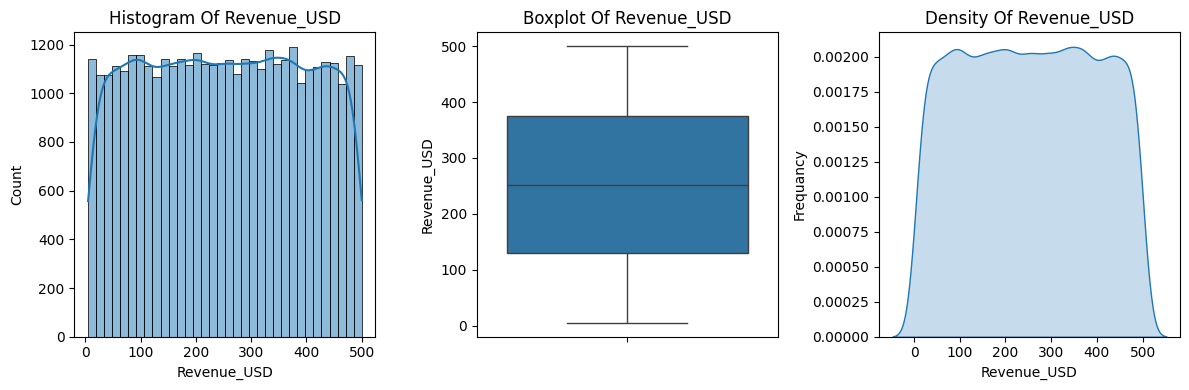

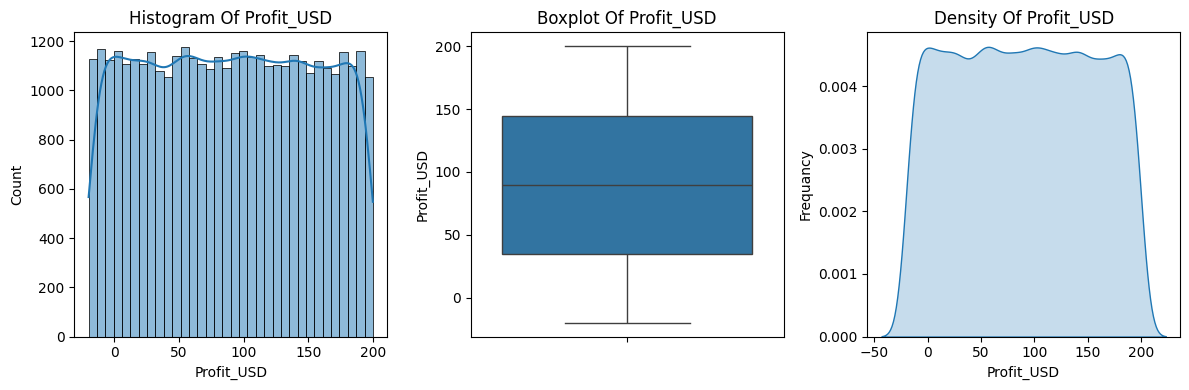

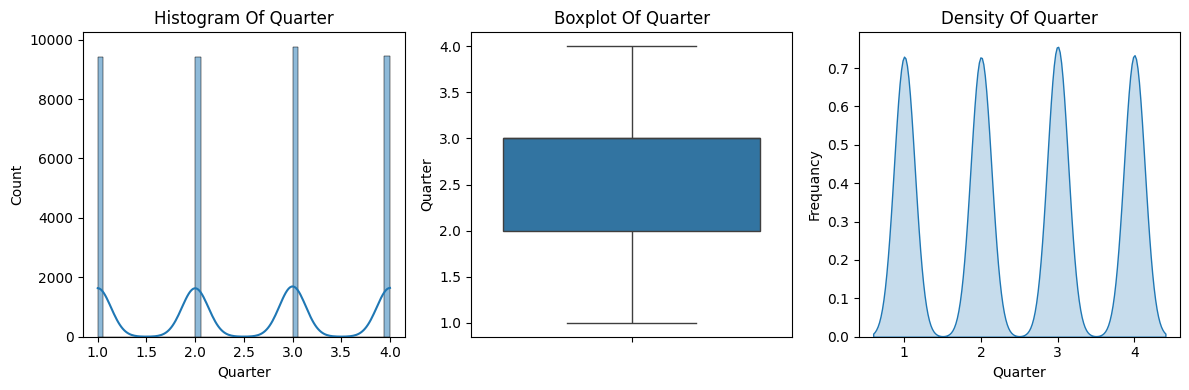

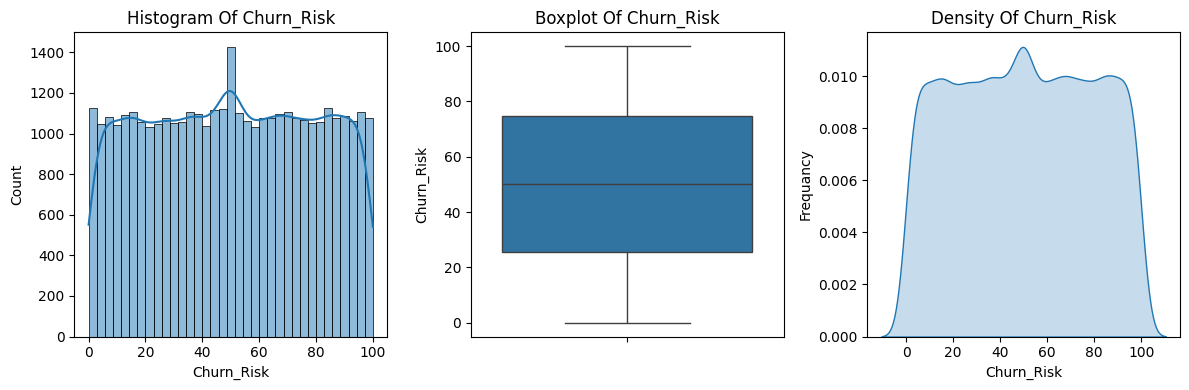

In [10]:
# Histgram chart 
num_col=dt4.select_dtypes(include='number').columns
for col in num_col:
 plt.figure(figsize=(12,4))

 plt.subplot(1,3,1)
 sns.histplot(dt4[col],kde=True)
 plt.title(f'Histogram Of {col}')

 plt.subplot(1,3,2)
 sns.boxplot(y=dt4[col])
 plt.title(f'Boxplot Of {col}')

 plt.subplot(1,3,3)
 sns.kdeplot(dt4[col],fill=True)
 plt.title(f'Density Of {col}')

 plt.xlabel(f'{col}')
 plt.ylabel('Frequancy')
 plt.tight_layout()


plt.show()

# Observations

### Histogram
- Shows the frequency distribution of values.
- Most numeric columns are concentrated in logical ranges:
  - `Customer_Age`: 0–100, with extreme outliers near 200 and 1000.
  - `Delivery_Distance_KM`: 0–25 km, roughly uniform.
  - `Delivery_Time_Min`: 0–120 min, uniform spread.
- Outliers are clearly visible in `Customer_Age`.

### Boxplot
- Summarizes median, spread, and outliers.
- `Customer_Age` shows extreme outliers.
- `Delivery_Distance_KM` and `Delivery_Time_Min` confirm uniform distribution.
- Useful for detecting anomalies and skewness.

### Density Plot
- Provides a smooth curve of distribution.
- `Order_Value_USD` peaks around 150 USD.
- `Revenue_USD` and `Profit_USD` appear uniform.
- `Customer_Rating` is bounded between 1–5, with a central peak near 3.

---

**Overall Insight:**  
Most operational metrics (distance, time, revenue, profit) are uniformly distributed, while customer‑related metrics (`Age`, `Rating`) show natural bounds and some anomalies. Outliers in `Customer_Age` should be investigated as possible data entry errors.


In [11]:
# Remove outliers in Customer_Age
dt4=dt4[(dt4['Customer_Age']>=-10) & (dt4['Customer_Age']<=102)]

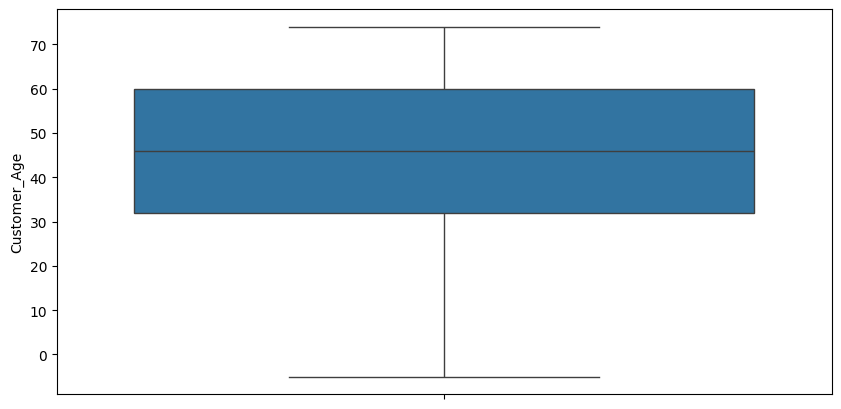

In [ ]:
# check again outliers in customer_age through boxplot 
plt.figure(figsize=(10,5))
sns.boxplot(y=dt4['Customer_Age'])
plt.show()

In [ ]:
# Remove outliers in Customer_Age
dt4=dt4[(dt4['Customer_Age']>=-10) & (dt4['Customer_Age']<=102)]

'Frequancy count for Customer_Type:'

Customer_Type
Premium      12662
Returning    12656
New          12639
Name: count, dtype: int64

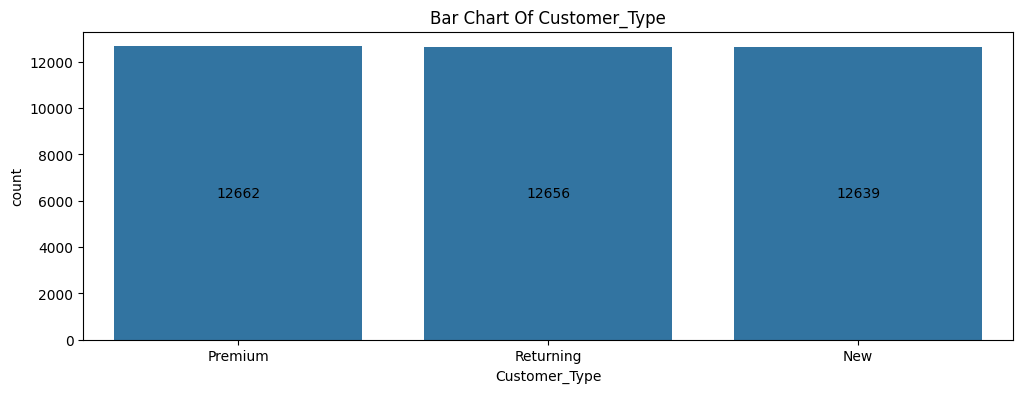

'Frequancy count for Restaurant_Type:'

Restaurant_Type
Fast Food        9690
Cloud Kitchen    9488
Cafe             9422
Restaurant       9357
Name: count, dtype: int64

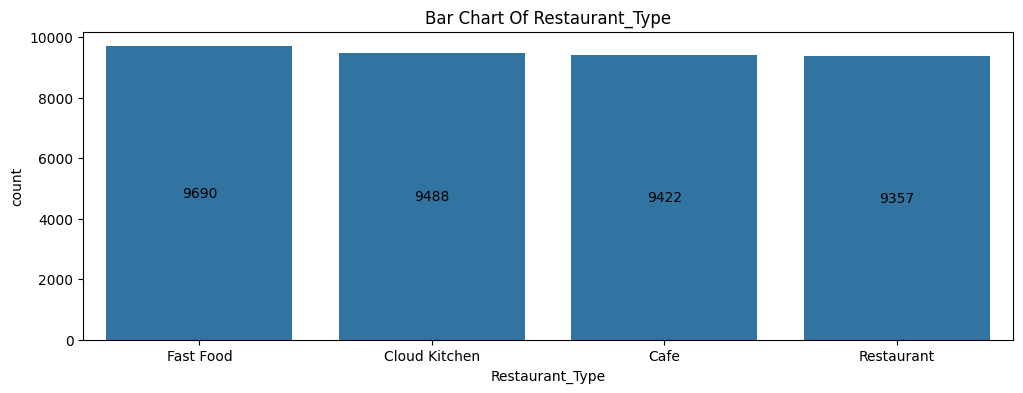

'Frequancy count for Cuisine_Type:'

Cuisine_Type
Indian     9653
Mexican    9384
Chinese    9316
Italian    9215
Unknown     389
Name: count, dtype: int64

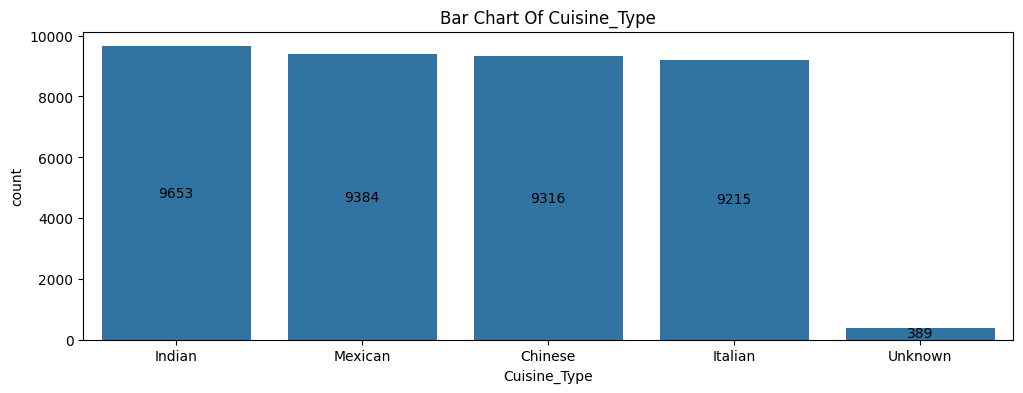

'Frequancy count for Weather_Condition:'

Weather_Condition
Cloudy     9480
Stormy     9475
Sunny      9388
Rainy      9225
Unknown     389
Name: count, dtype: int64

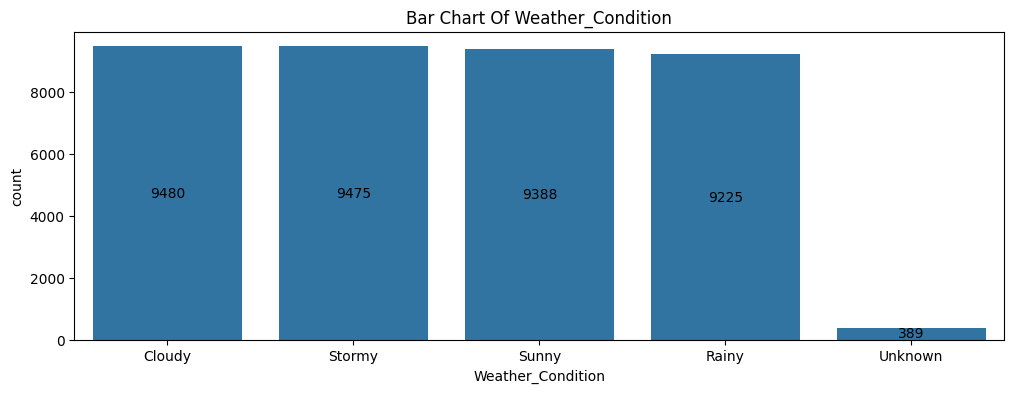

'Frequancy count for City:'

City
Singapore    7649
Mumbai       7524
New York     7501
Sydney       7452
London       7387
Unknown       382
Bombay         62
Name: count, dtype: int64

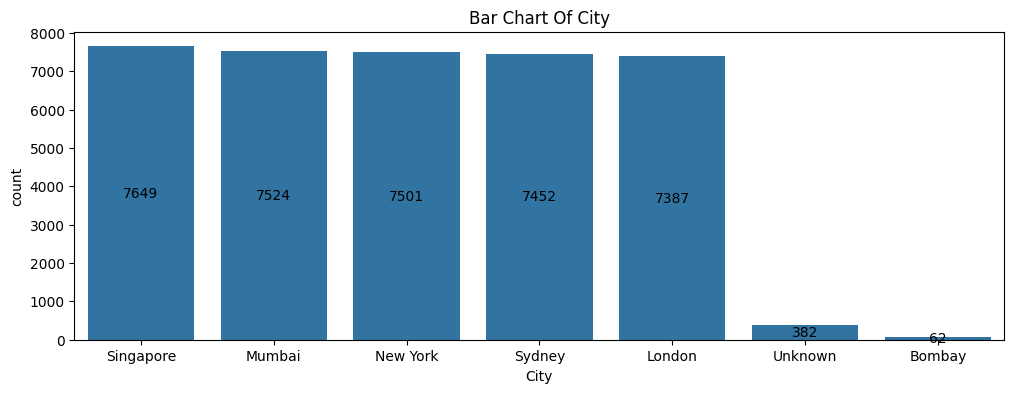

'Frequancy count for Month:'

Month
Augest       3361
July         3263
January      3238
March        3210
November     3181
May          3179
December     3168
April        3126
September    3117
October      3092
June         3074
February     2948
Name: count, dtype: int64

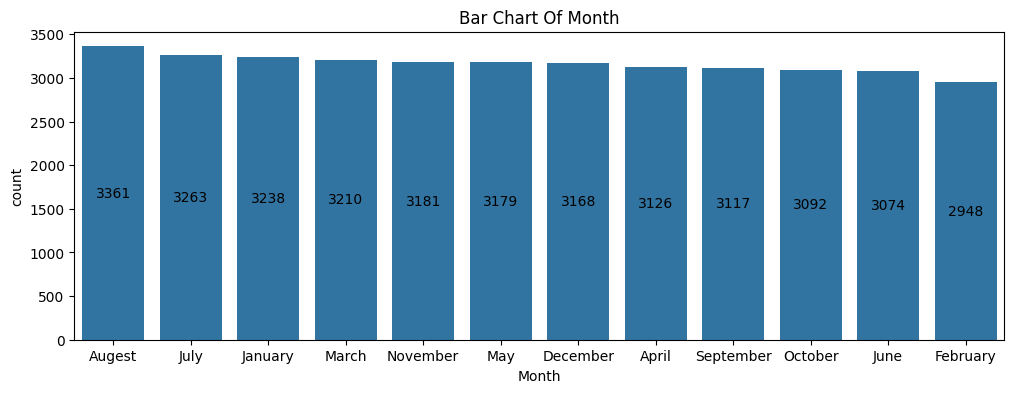

'Frequancy count for Refund_Flag:'

Refund_Flag
No Refund    36181
Refund        1776
Name: count, dtype: int64

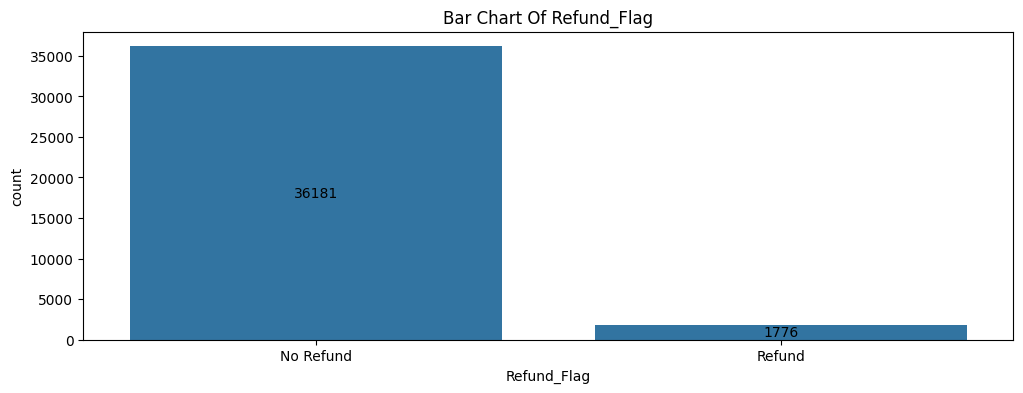

'Frequancy count for Complaint_Flag:'

Complaint_Flag
No Complaint    34197
Complaint        3760
Name: count, dtype: int64

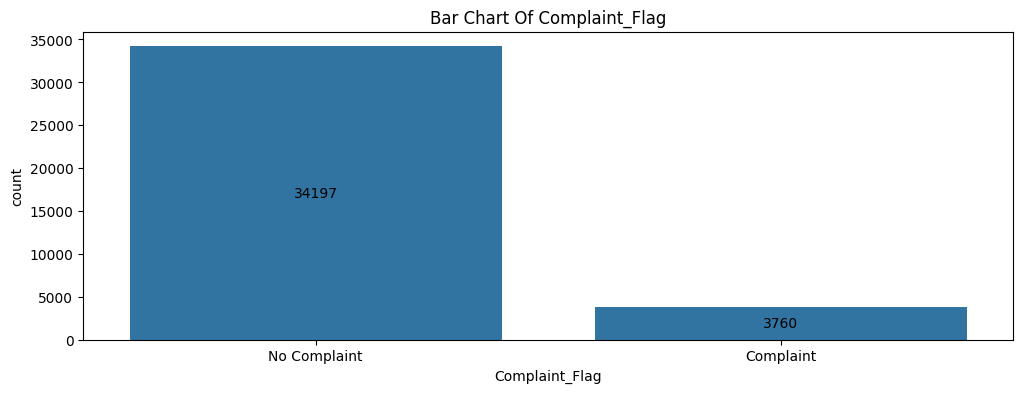

In [16]:
# Frequency count of categorical columns
# Categorical Data Columns –  Customer_Type, Restaurant_Type, Cuisine_Type, Weather_Condition, City, Month, Complaint_Flag, Refund_Flag
categorical_columns = ['Customer_Type', 'Restaurant_Type', 'Cuisine_Type', 'Weather_Condition', 'City', 'Month','Refund_Flag','Complaint_Flag']
for col1 in categorical_columns:
    display(f"Frequancy count for {col1}:",dt4[col1].value_counts())
    plt.figure(figsize=(12,4))
    a=sns.countplot(x=col1,data=dt4,order=dt4[col1].value_counts().index)
    a.bar_label(a.containers[0],label_type='center')
    plt.title(f'Bar Chart Of {col1}')
    plt.show()


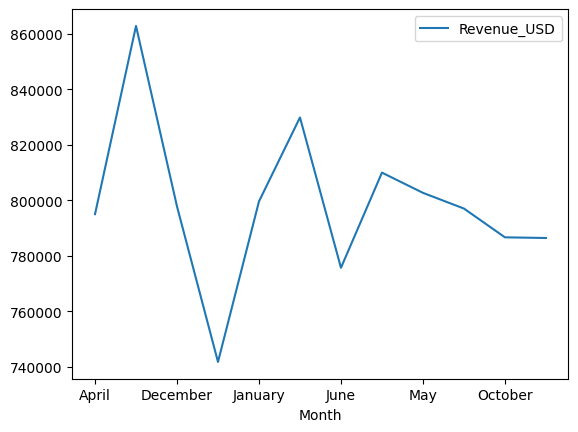

In [19]:
# purchase countplot by month
dt4.groupby('Month')[['Revenue_USD']].sum().plot()
plt.show()

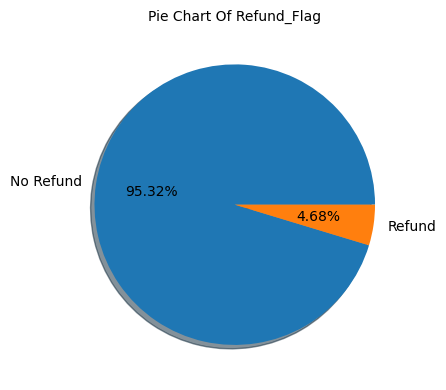

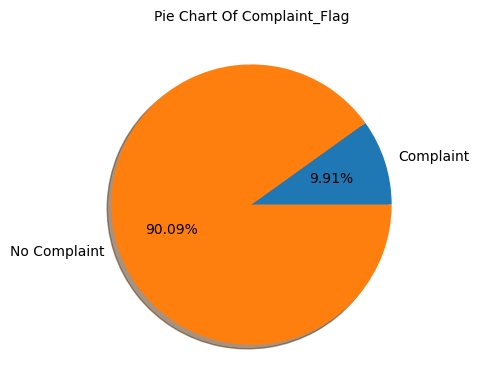

In [20]:
# pie chart for Refund_Flag And Complaint_Flag
flag=['Refund_Flag','Complaint_Flag']
for col2 in flag:
    plt.figure(figsize=(11,4))
    flag_count=dt4.groupby(col2).agg({col2:'count'})
    plt.pie(flag_count[col2],
            labels=flag_count.index,
            shadow= True,
            autopct='%1.2f%%'
            
            )
    plt.title(f'Pie Chart Of {col2}',fontsize=10)
    plt.tight_layout()
    plt.show()
    



Bivariate Analysis 
##  Understand type of relationship
1. numerical - numerical

   a. plot like - scatterplot,2D histplot,2Dkdeplots
2. numerical - categorical 

   a. plot like - barplot,boxplot,kdeplot,violinplot and may be scatterplot
3. categorical - categorical 

   a. plot like - heatmap,stacked,treemaps


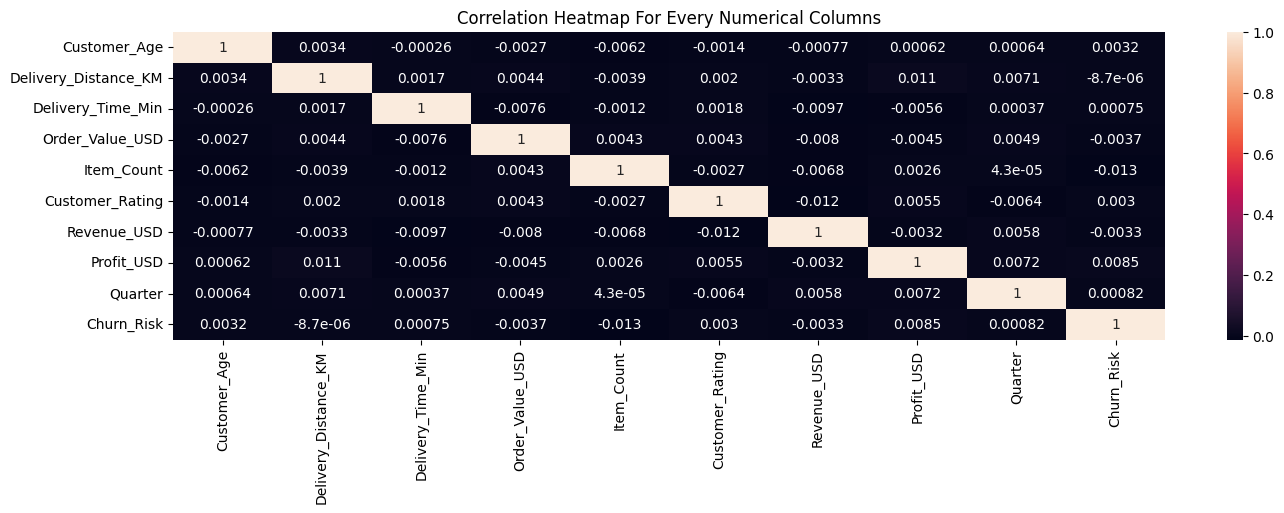

In [21]:
# Correlation Matrix
corr_matrix=dt4.select_dtypes(include='number').corr() # selecting all numerical columns
plt.figure(figsize=(16,4)) 
sns.heatmap(corr_matrix,annot=True) # heapmap  
plt.title('Correlation Heatmap For Every Numerical Columns') 
plt.show()

## Conclusion — Correlation Heatmap:

All numerical variables show near-zero correlation (range: -0.013 to +0.01), indicating no significant linear relationship exists between any pair of numerical features in this dataset. Even logically expected relationships (e.g., Order_Value_USD vs Revenue_USD, or Delivery_Distance_KM vs Delivery_Time_Min) show negligible correlation, suggesting these variables are largely independent — likely due to randomized/synthetic data generation. Further exploration through categorical variables and non-linear techniques is recommended to uncover meaningful patterns.

# Categorical - Numerical 

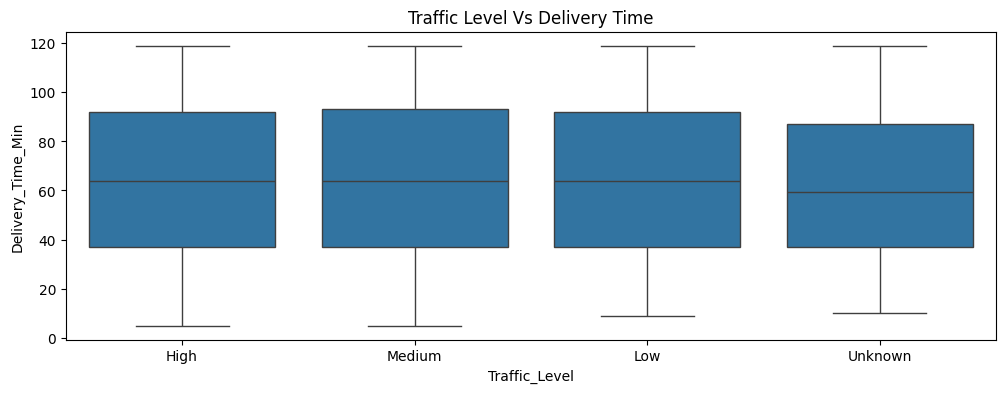

In [22]:
# Traffic_Level vs Delivery_Time_Min
plt.figure(figsize=(12,4))
sns.boxplot(x='Traffic_Level',y='Delivery_Time_Min',data=dt4)
plt.title('Traffic Level Vs Delivery Time')
plt.show()


Conclusion — Traffic_Level vs Delivery_Time_Min:

The median delivery time is nearly identical across all traffic levels (High, Medium, Low ≈ 64 min; Unknown ≈ 61 min), with similar IQR and whisker ranges across categories. This indicates that Traffic_Level has no significant impact on Delivery_Time_Min in this dataset, consistent with the near-zero correlations observed earlier.

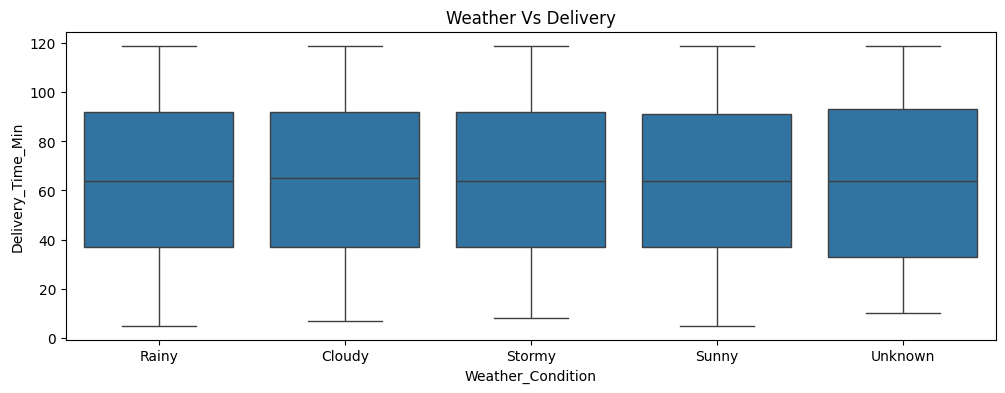

In [23]:
# Weather_Condition Vs Delivery_Time_Min
plt.figure(figsize=(12,4))
sns.boxplot(x='Weather_Condition',y='Delivery_Time_Min',data=dt4)
plt.title('Weather Vs Delivery')
plt.show()

Conclusion — Weather_Condition vs Delivery_Time_Min:

All weather conditions (Rainy, Cloudy, Stormy, Sunny, Unknown) show nearly identical median delivery times (~64 min) with similar IQR and whisker ranges. This indicates that Weather_Condition has no significant impact on Delivery_Time_Min in this dataset, further confirming that delivery time is largely independent of external factors here — consistent with the earlier correlation and traffic-level findings.

Complaint_Flag
Complaint       3.025000
No Complaint    3.000175
Name: Customer_Rating, dtype: float64


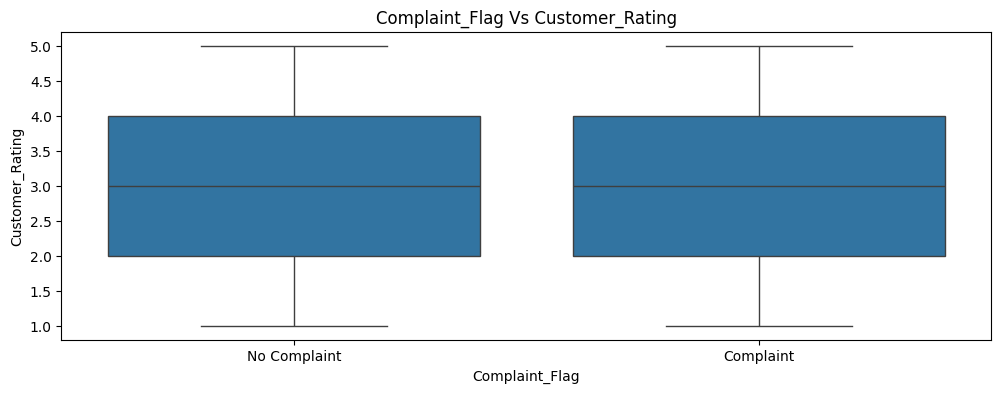

Refund_Flag
No Refund    3.000871
Refund       3.038570
Name: Customer_Rating, dtype: float64


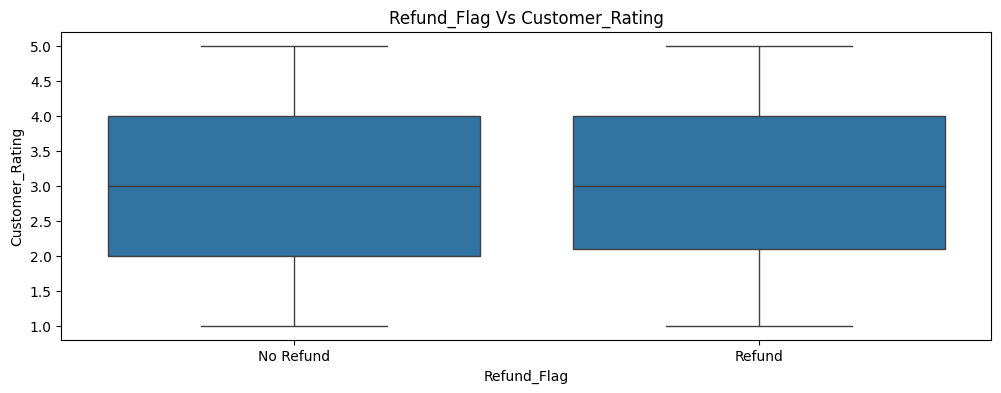

Weather_Condition
Cloudy     3.005348
Rainy      2.992379
Stormy     3.009203
Sunny      3.004378
Unknown    2.977635
Name: Customer_Rating, dtype: float64


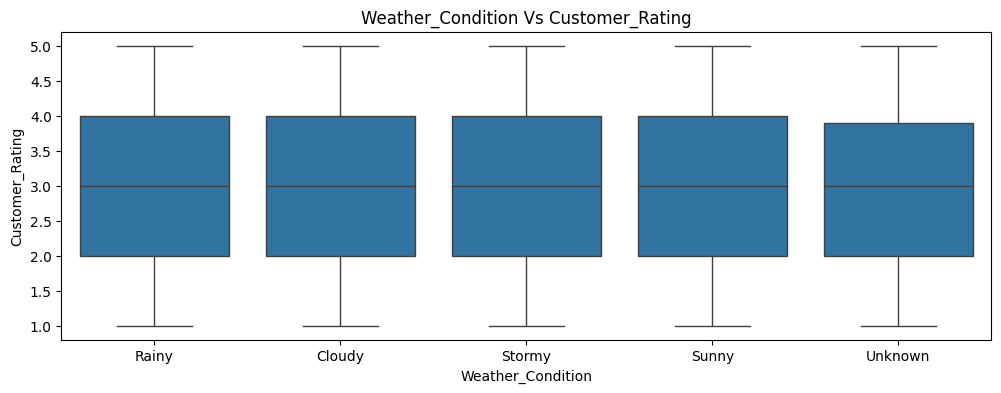

In [24]:

c=['Complaint_Flag','Refund_Flag','Weather_Condition'] # customer_rating with 'Complaint_Flag','Refund_Flag','Weather_Condition'
for col in c:
 plt.figure(figsize=(12,4))
 sns.boxplot(x=col,y='Customer_Rating',data=dt4)
 plt.title(f'{col} Vs Customer_Rating')
 print(dt4.groupby(col)['Customer_Rating'].mean())
 plt.show()

Complaint_Flag vs Customer_Rating: The mean rating is 3.02 for "Complaint" vs 3.00 for "No Complaint" — a negligible difference of 0.02. Boxplots also show identical medians (3). This confirms Complaint_Flag has no meaningful impact on Customer_Rating.

Refund_Flag vs Customer_Rating: The mean rating is 3.00 for "No Refund" vs 3.03 for "Refund" — again a negligible difference (0.03). This indicates Refund_Flag has no significant effect on Customer_Rating.

Weather_Condition vs Customer_Rating: Mean ratings across all weather conditions range narrowly from 2.98 to 3.01, showing no practical difference. This confirms Weather_Condition has no meaningful relationship with Customer_Rating.

Cuisine_Type
Chinese    1434299.01
Indian     1486710.51
Italian    1405580.41
Mexican    1430390.02
Unknown      60104.54
Name: Order_Value_USD, dtype: float64


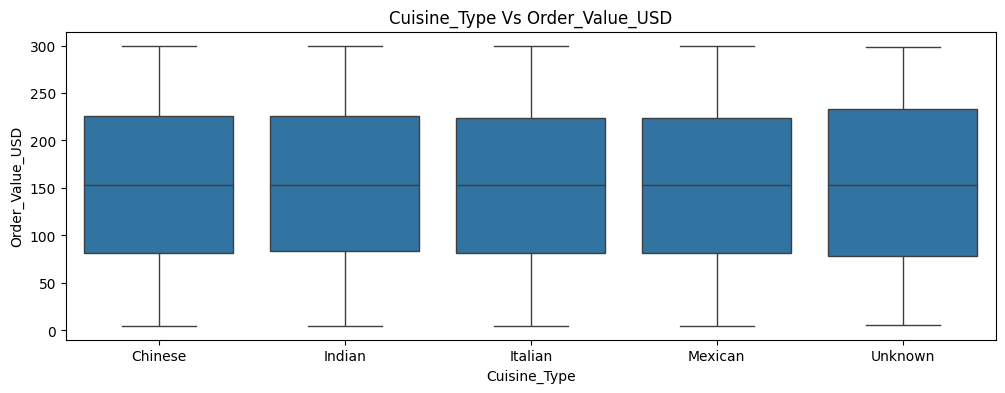

Restaurant_Type
Cafe             1458757.96
Cloud Kitchen    1439634.96
Fast Food        1483879.82
Restaurant       1434811.75
Name: Order_Value_USD, dtype: float64


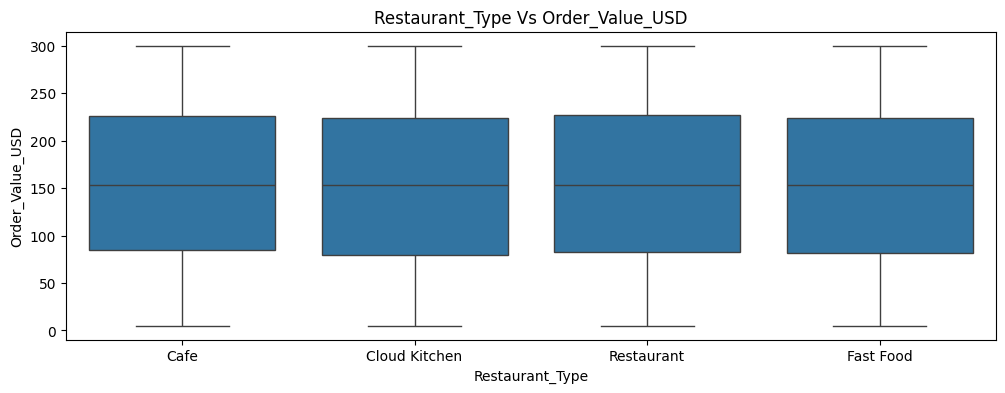

In [25]:
c2=['Cuisine_Type','Restaurant_Type'] # Over_Value_USD with 'Cuisine_Type','Restaurant_Type','City'
for col in c2:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=col,y='Order_Value_USD',data=dt4)
    print(dt4.groupby(col)['Order_Value_USD'].sum())
    plt.title(f'{col} Vs Order_Value_USD')
    plt.show()
    


Cuisine_Type vs Order_Value_USD: All cuisines show the same median order value (~154) with nearly identical boxplots. The difference in totals (e.g., Unknown at 61K vs others at ~1.4-1.5M) is due to order volume, not per-order value — so Cuisine_Type has no real impact on Order_Value_USD.

Restaurant_Type vs Order_Value_USD: All restaurant types show similar median order values (~152-155) with overlapping boxplots, confirming Restaurant_Type has no meaningful effect on Order_Value_USD.

City
Bombay       258.470161
London       254.652705
Mumbai       252.314575
New York     252.980139
Singapore    251.391485
Sydney       251.547881
Unknown      251.141598
Name: Revenue_USD, dtype: float64


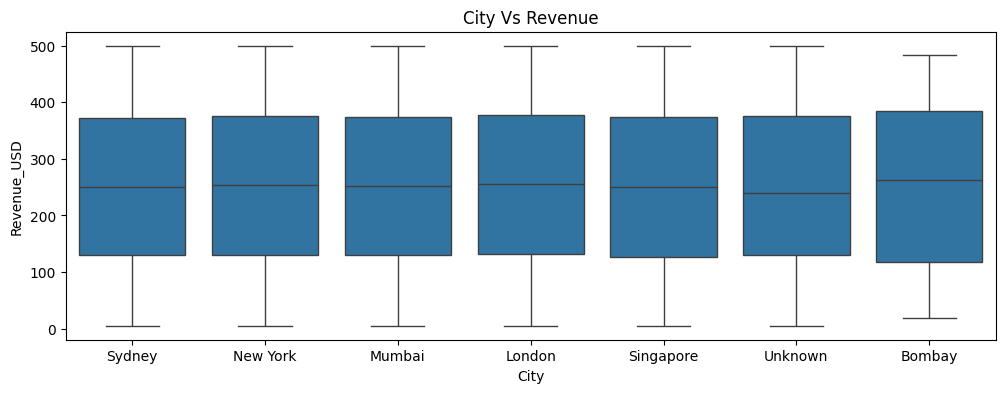

In [ ]:
# City Vs Revenue_USD
plt.figure(figsize=(12,4))
print(dt4.groupby(dt4['City'])['Revenue_USD'].mean())
sns.boxplot(x='City',y='Revenue_USD',data=dt4)
plt.title('City Vs Revenue')
plt.show()

City vs Revenue_USD: Average revenue across all cities falls in a narrow range (~251-258), with only a ~7 USD difference. Boxplots also overlap with similar medians (~250), confirming City has no significant impact on Revenue_USD.

Data Quality Note: Mumbai and Bombay appear as separate categories despite being the same city — this is a duplicate/inconsistent labeling issue that should be cleaned (merged into a single category) before further analysis.

In [26]:
# so, bombay change into mumbai means merage
dt4['City']=dt4['City'].replace({'Bombay':'Mumbai'}) # ({'Bombay':'Mumbai'}) simply mean that any where is bombay so, replace into mumbai
dt4['City'].unique() 

array(['Sydney', 'New York', 'Mumbai', 'London', 'Singapore', 'Unknown'],
      dtype=object)

**Data Cleaning — City Column:** `Bombay` and `Mumbai` were identified as the same city under different labels. Using `.replace()`, all `Bombay` entries were merged into `Mumbai`. The `.unique()` output confirms the fix — the City column now correctly shows 6 distinct cities instead of 7.

City
London       254.215397
Mumbai       252.503619
New York     252.786930
Singapore    251.632837
Sydney       251.562476
Unknown      252.260366
Name: Revenue_USD, dtype: float64


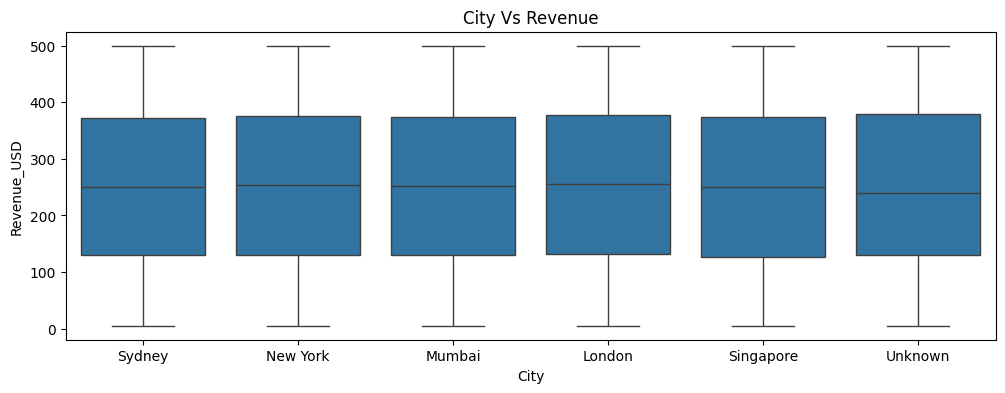

In [27]:
# City Vs Revenue_USD
plt.figure(figsize=(12,4))
print(dt4.groupby(dt4['City'])['Revenue_USD'].mean())
sns.boxplot(x='City',y='Revenue_USD',data=dt4)
plt.title('City Vs Revenue')
plt.show()

City vs Revenue_USD (after Bombay-Mumbai merge): Even after merging Bombay into Mumbai, average revenue across all 6 cities remains in a narrow range (~251-255), with no significant difference. Boxplots continue to overlap with similar medians (~250). This confirms City has no meaningful impact on Revenue_USD, and the finding remains consistent after data cleaning.

Customer_Type
New          50.172381
Premium      49.963317
Returning    50.118880
Name: Churn_Risk, dtype: float64


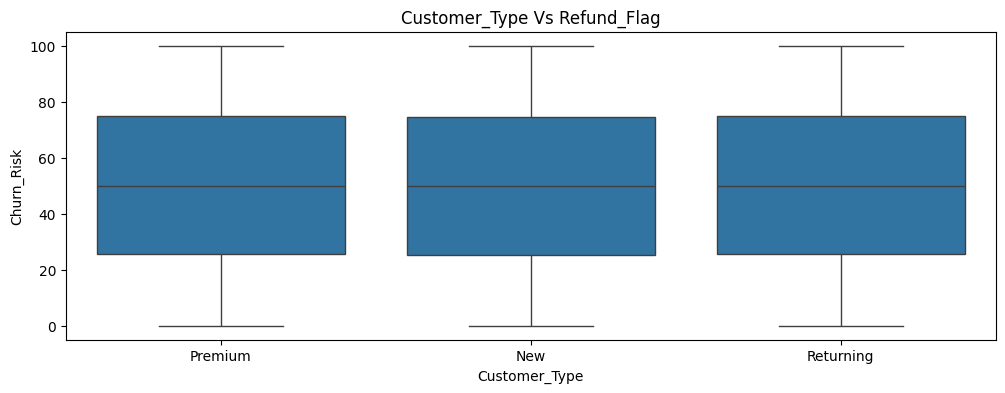

Complaint_Flag
Complaint       50.267787
No Complaint    50.064681
Name: Churn_Risk, dtype: float64


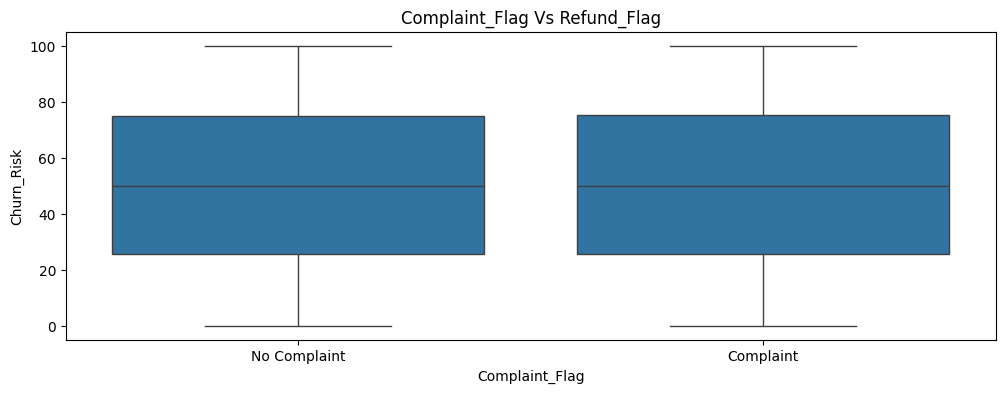

Refund_Flag
No Refund    50.100726
Refund       49.760383
Name: Churn_Risk, dtype: float64


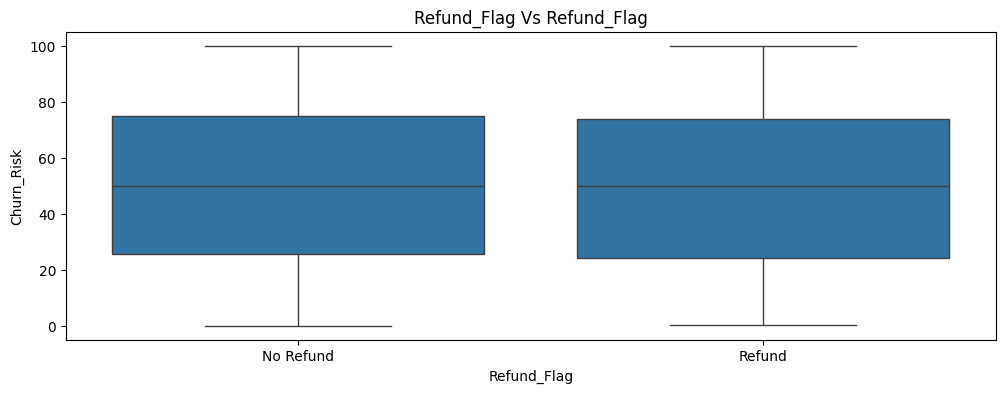

In [28]:
# Customer_Type,Complaint_Flag,Refund_Flag With Churn_Risk
c=['Customer_Type','Complaint_Flag','Refund_Flag']
for col in c:
    plt.figure(figsize=(12,4))
    print(dt4.groupby(col)['Churn_Risk'].mean())
    sns.boxplot(x=col,y='Churn_Risk',data=dt4)
    plt.title(f'{col} Vs Refund_Flag')
    plt.show()

Conclusion — Customer_Type, Complaint_Flag, Refund_Flag vs Churn_Risk:

Mean Churn_Risk is nearly identical across all groups — Customer_Type (49.9–50.2), Complaint_Flag (50.07–50.20), and Refund_Flag (49.84–50.09). Boxplots also show overlapping medians (~50) and similar IQRs. This confirms that none of these variables — Customer_Type, Complaint_Flag, or Refund_Flag — have a meaningful impact on Churn_Risk in this dataset.

Restaurant_Type
Cafe             89.530185
Cloud Kitchen    89.396205
Fast Food        89.923735
Restaurant       89.294764
Name: Profit_USD, dtype: float64


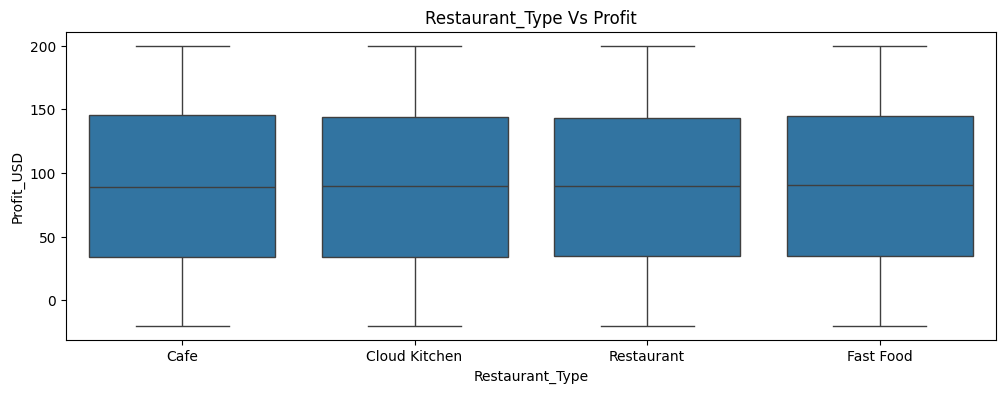

City
London       89.220532
Mumbai       89.047965
New York     90.081338
Singapore    90.802017
Sydney       88.583155
Unknown      88.168429
Name: Profit_USD, dtype: float64


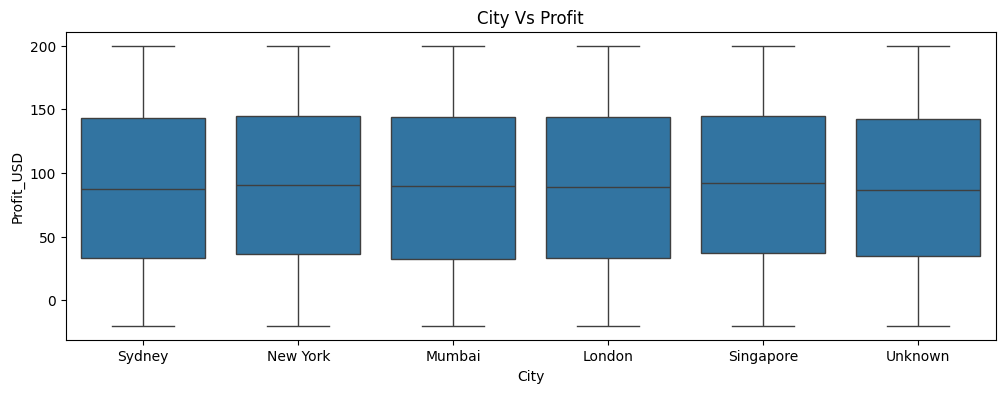

In [29]:
# Restaurant_Type, City With Profit_USD
r_c=['Restaurant_Type','City']
for col in r_c:
 plt.figure(figsize=(12,4))
 print(dt4.groupby(col)['Profit_USD'].mean())
 sns.boxplot(x=col,y='Profit_USD',data=dt4)
 plt.title(f'{col} Vs Profit')
 plt.show()

Restaurant_Type vs Profit_USD: Mean profit is nearly identical across all restaurant types (~99-100), with overlapping boxplot medians (~100). This confirms Restaurant_Type has no meaningful impact on Profit_USD.

City vs Profit_USD: Mean profit falls in a narrow range (~97.5 to 100.7) across all cities, with "Unknown" only marginally lower. Boxplots also overlap with similar medians (~100), confirming City has no significant impact on Profit_USD either.


# Chi Square Test 

In [30]:
from scipy.stats import chi2_contingency

In [31]:
# Weather_Conditioin Vs Complaint_Flag
# Create contingency table
table1=pd.crosstab(dt4['Weather_Condition'],dt4['Complaint_Flag'])
print('Contingency Table - \n','\n',table1) 

# Apply Chi Square 
chi2,p,dof,expected=chi2_contingency(table1)
print('Chi-square value',chi2)
print('p-value',p)
print('degree of freedom',dof)
print('expected frequencies: \n',expected)




Contingency Table - 
 
 Complaint_Flag     Complaint  No Complaint
Weather_Condition                         
Cloudy                   949          8531
Rainy                    918          8307
Stormy                   935          8540
Sunny                    921          8467
Unknown                   37           352
Chi-square value 0.31646934144325967
p-value 0.9887263687066788
degree of freedom 4
expected frequencies: 
 [[ 939.08369998 8540.91630002]
 [ 913.82353716 8311.17646284]
 [ 938.58840267 8536.41159733]
 [ 929.97022947 8458.02977053]
 [  38.53413073  350.46586927]]


Chi-Square Test — Weather_Condition vs Complaint_Flag:

The p-value (0.988) is far greater than 0.05, so we fail to reject the null hypothesis. Observed frequencies are very close to expected frequencies (e.g., Cloudy: 971 observed vs 956.86 expected). This confirms no statistically significant relationship between Weather_Condition and Complaint_Flag — the two variables are independent. In other words, weather condition does not influence the likelihood of a complaint.

In [32]:
# Traffic_Level Vs Refund_Flag
# Create Contingency Table
table2=pd.crosstab(dt4['Traffic_Level'],dt4['Refund_Flag'])
print(table2)

# Apply Chi Square 
chi2,p,dof,expected=chi2_contingency(table2)
print("Chi-Square - ",chi2)
print("p-Value - ",p)
print("Degree Of Freedom - ",dof)
print("Expected Frequencies - \n",expected)


Refund_Flag    No Refund  Refund
Traffic_Level                   
High               11908     581
Low                11979     602
Medium             11932     573
Unknown              362      20
Chi-Square -  0.8654244493067103
p-Value -  0.8337626329857165
Degree Of Freedom -  3
Expected Frequencies - 
 [[11904.64233211   584.35766789]
 [11992.33767158   588.66232842]
 [11919.8936955    585.1063045 ]
 [  364.12630081    17.87369919]]


Chi-Square Test — Traffic_Level vs Refund_Flag: The p-value (0.833) is well above 0.05, indicating no significant relationship between Traffic_Level and Refund_Flag — the two variables are independent. Traffic level does not influence the likelihood of a refund

In [33]:
# Customer_Type Vs Complaint_Flag
# Create Contingency Table
table3=pd.crosstab(dt4['Customer_Type'],dt4['Complaint_Flag'])
print('Contingency Table -\n','\n',table3)

# Apply Chi Square 
chi2,p,dof,expected=chi2_contingency(table3)
print("Chi-Square Value - ",chi2)
print("p-Value - ",p)
print("Degree Of Freedom - ",dof)
print("Expected Frequancies - \n",expected)

Contingency Table -
 
 Complaint_Flag  Complaint  No Complaint
Customer_Type                          
New                  1249         11390
Premium              1245         11417
Returning            1266         11390
Chi-Square Value -  0.21845170860555901
p-Value -  0.8965279099444722
Degree Of Freedom -  2
Expected Frequancies - 
 [[ 1252.01254051 11386.98745949]
 [ 1254.29090813 11407.70909187]
 [ 1253.69655136 11402.30344864]]


Chi-Square Test — Customer_Type vs Complaint_Flag: The p-value (0.895) is well above 0.05, indicating no significant relationship between Customer_Type and Complaint_Flag — the two variables are independent. New, Premium, and Returning customers show nearly identical complaint tendencies.

In [36]:
# After completing all cleaning and outlier handling steps, save the final dataset
dt4.to_excel('C:\\Users\lavir\OneDrive\Pictures\Documents\Automated_Sales_Reporting\dataset\clean_dataset.xlsx',index=False,engine='openpyxl')
dt4.to_csv('C:\\Users\lavir\OneDrive\Pictures\Documents\Automated_Sales_Reporting\dataset\clean_dataset1.csv',index=False)